<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/loan_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loan Approval Prediction

Dataset (Recommended): Loan-Approval-Prediction-Dataset (Kaggle)

Build a model to predict whether a loan application will be approved

Handle missing values and encode categorical features

Train a classification model and evaluate performance on imbalanced data

Focus on precision, recall, and F1-score
## Binary Classification

Imbalanced data


##Bonus:
Use SMOTE or other techniques to address class imbalance
Try logistic regression vs. decision tree

**SMOTE** (Synthetic Minority Over-sampling Technique) to ensure our models don't become biased toward the majority class.

In [55]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score)

In [57]:
df= pd.read_csv('loan_approval_dataset.csv')


In [58]:
print(f'Shape of Dataset: {df.shape}')
print('\nDataset Preview (First 5 Rows):\n')
display(df.head())
print('\nDataset Preview (Last 5 Rows):\n')
display(df.tail())

Shape of Dataset: (4269, 13)

Dataset Preview (First 5 Rows):



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Dataset Preview (Last 5 Rows):



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


Cleaning

In [59]:
df.columns = df.columns.str.strip()
df = df.drop('loan_id', axis=1)
obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())

Checking for missing values

In [60]:
print("Missing Values in Data:", df.isnull().sum().sum())
print("Duplicated Values in Data:", df.duplicated().sum())

df.info()


Missing Values in Data: 0
Duplicated Values in Data: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [61]:
print("Numerical Statistics:")
display(df.describe().T)

print("\nCategorical Statistics:")
display(df.describe(include='object').T)

Numerical Statistics:


,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0



Categorical Statistics:


,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656


Exploratory Data Analysis

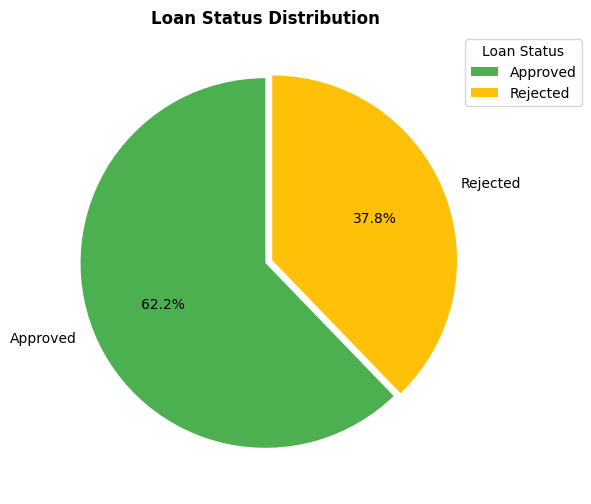

In [62]:
plt.figure(figsize=(10, 6))
explode = (0, 0.04)
plt.pie(x=status_counts.values, labels=status_counts.index, explode=explode, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FFC107'])
plt.legend(
    status_counts.index,
    title="Loan Status",
    loc="upper right",
    bbox_to_anchor=(1.2, 1))
plt.title('Loan Status Distribution', fontweight='bold')
plt.show()

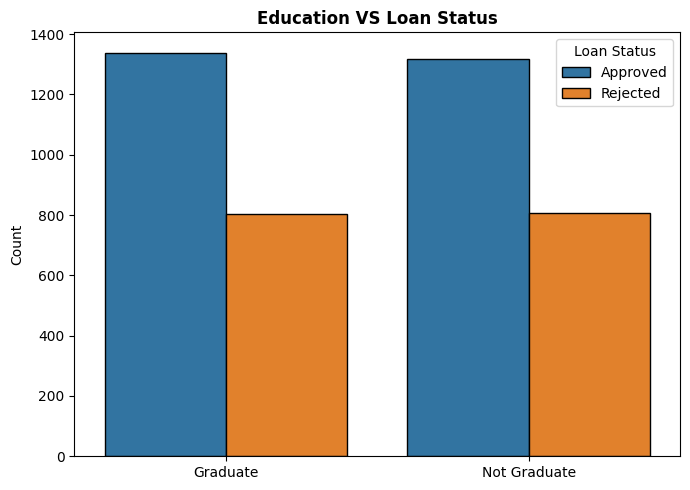

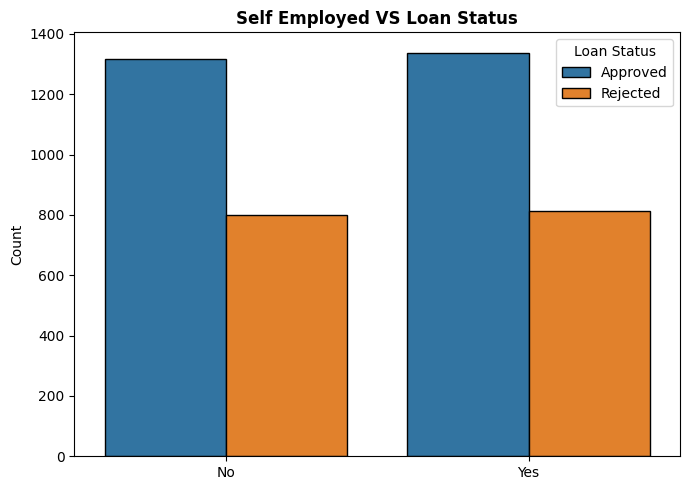

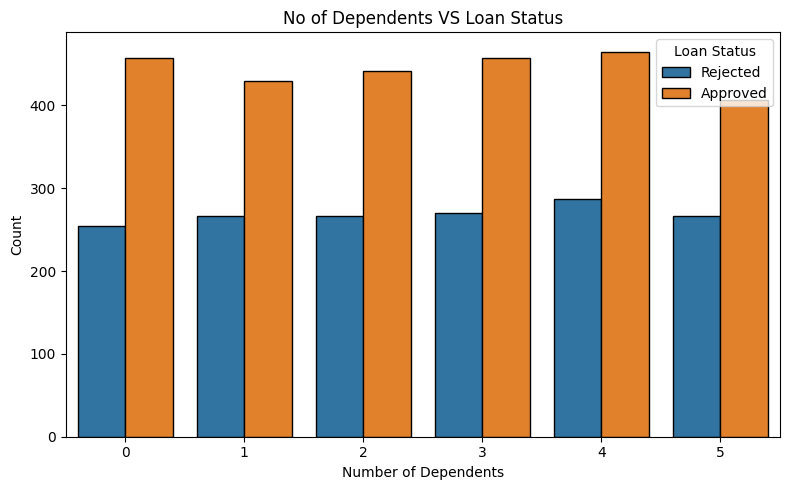

In [63]:
target = "loan_status"
categorical_cols = [col for col in df.select_dtypes(include='object').columns if col != target]
for col in categorical_cols:
    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=df, x=col,hue=target,

        edgecolor='k' )
    plt.title(f"{col.replace('_',' ').title()} VS {target.replace('_',' ').title()}", fontweight='bold')
    plt.ylabel("Count")
    plt.xlabel("")
    plt.legend(title="Loan Status", loc='upper right')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, x='no_of_dependents',
    hue='loan_status',
    edgecolor='black')
plt.title("No of Dependents VS Loan Status")
plt.ylabel("Count")
plt.xlabel("Number of Dependents")
plt.legend(title="Loan Status", loc='upper right')
plt.tight_layout()
plt.show()

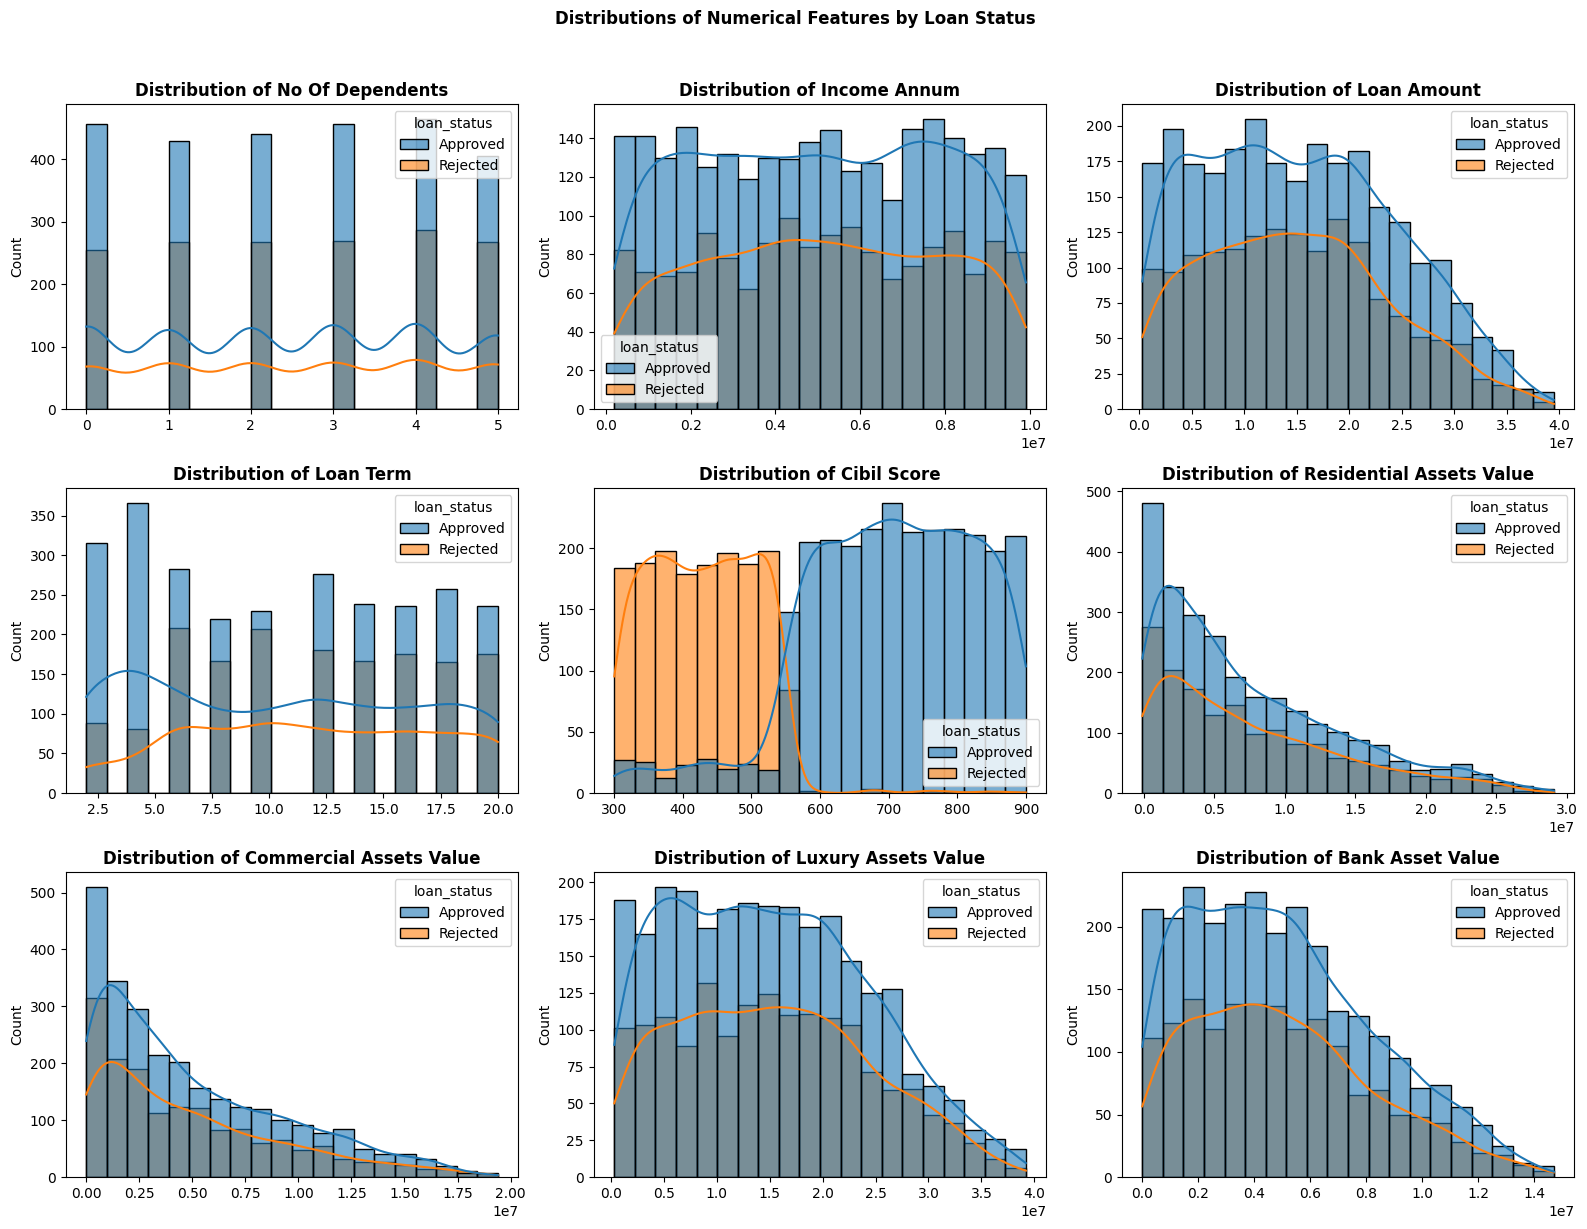

In [64]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col,
        hue='loan_status', kde=True, ax=axes[i],
        bins=20, alpha=0.6, edgecolor='k')

    clean_title = col.replace('_', ' ').title()
    axes[i].set_title(f"Distribution of {clean_title}", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distributions of Numerical Features by Loan Status', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


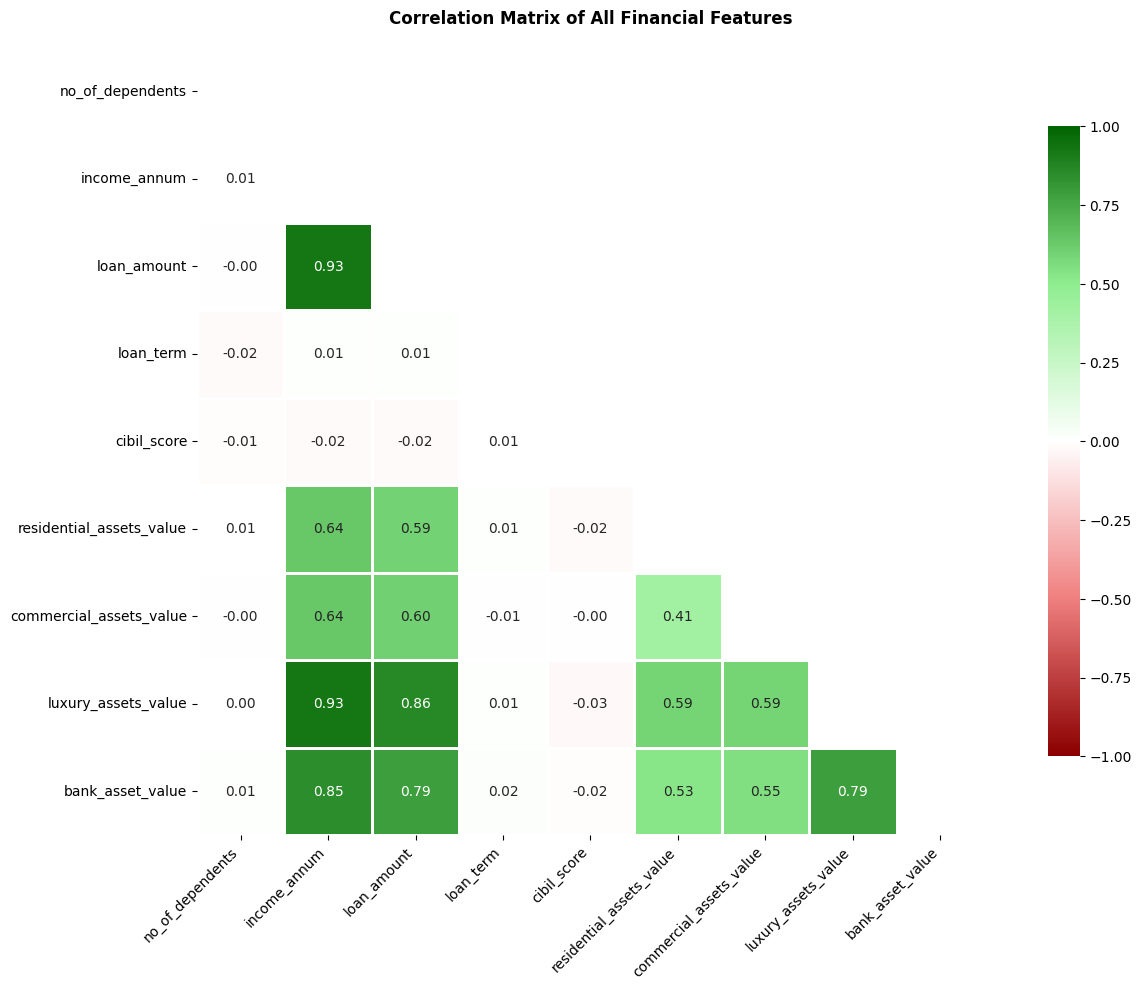

In [66]:
custom_cmap = LinearSegmentedColormap.from_list("custom_diverging",
    ["darkred", "lightcoral", "white", "lightgreen", "darkgreen"]) # Define a custom diverging colormap

plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask,
    annot=True, fmt=".2f",
    cmap=custom_cmap, vmin=-1, vmax=1,
    linewidths=1, linecolor='white',
    square=True, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of All Financial Features', fontweight='bold', y=1.02)
plt.xticks(rotation=45, ha='right')
plt.yticks()

plt.tight_layout()
plt.show()

Encoding Categorical Features

In [67]:
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})

X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data split completed — Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}.")

Data split completed — Training rows: 3415, Testing rows: 854.


In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Target distribution before SMOTE (in training data):")
print(y_train.value_counts())
print("-" * 30)
print("Target distribution after SMOTE (perfect balance):")
print(y_train_smote.value_counts())

Target distribution before SMOTE (in training data):
loan_status
1    2125
0    1290
Name: count, dtype: int64
------------------------------
Target distribution after SMOTE (perfect balance):
loan_status
1    2125
0    2125
Name: count, dtype: int64


In [69]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)
y_pred_log = log_reg.predict(X_test_scaled)

tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_clf.fit(X_train_smote, y_train_smote)
y_pred_tree = tree_clf.predict(X_test_scaled)


rf_clf = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100)
rf_clf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_clf.predict(X_test_scaled)

In [70]:
target_labels = ['Rejected (0)', 'Approved (1)']
#Logistic Regression Performance
print("[1] Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log, target_names=target_labels))

#Decision  Tree Performance
print("\n[2] Decision Tree Performance:")
print(classification_report(y_test, y_pred_tree, target_names=target_labels))

#Random Forest Performance
print("\n[3] Random Forest Performance (Ensemble):")
print(classification_report(y_test, y_pred_rf, target_names=target_labels))

[1] Logistic Regression Performance:
              precision    recall  f1-score   support

Rejected (0)       0.88      0.92      0.90       323
Approved (1)       0.95      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854


[2] Decision Tree Performance:
              precision    recall  f1-score   support

Rejected (0)       0.95      0.97      0.96       323
Approved (1)       0.98      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854


[3] Random Forest Performance (Ensemble):
              precision    recall  f1-score   support

Rejected (0)       0.95      0.99      0.97       323
Approved (1)       0.99      0.97      0.98       531

    accuracy                           0.97       854
   macro avg    

Feature importance

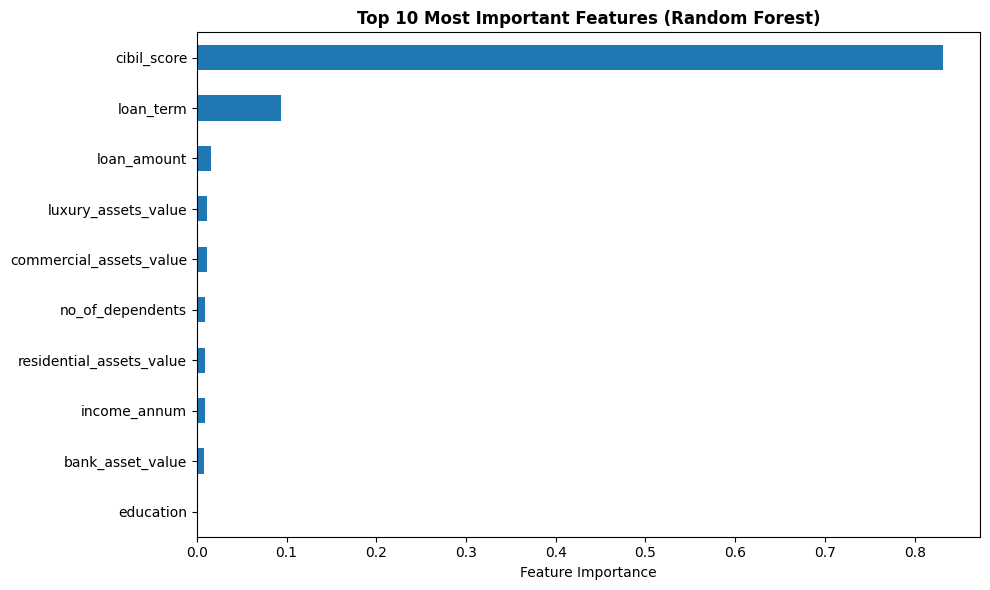

In [71]:
importances = rf_clf.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values(ascending=False).head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Most Important Features (Random Forest)", fontweight='bold')
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

In [72]:
models = ['Logistic Regression','Decision Tree','Random Forest']
scores = [
log_reg.score(X_test_scaled,y_test),
tree_clf.score(X_test_scaled,y_test),
rf_clf.score(X_test_scaled,y_test)
]

pd.DataFrame({
'Model':models,
'Accuracy':scores
})

,Model,Accuracy
0,Logistic Regression,0.922717
1,Decision Tree,0.970726
2,Random Forest,0.974239


For this dataset Random Forst gives us the best result with accuracy of 0.974